# SECP3133 High Performance Data Processing
## Assignment 2: Mastering Big Data Handling

**Group Name:** Boeing 737  
**Member 1:** Sabrina Heng Wei Qi (A23CS0265)  
**Member 2:** Woo Cheng Shuan (A23CS0283)  
**Section:** 02  

---
### Purpose
This notebook implements and measures five distinct big data handling strategies—column projection, chunking, data type downcasting, sampling, and multi-core parallel processing—on a 1.22 GB dataset containing over 7.2 million records. It establishes a single-threaded Pandas baseline and contrasts it against Dask and Polars engines.

# **1. Environment Setup & Drive Mounting**


In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Install required libraries
!pip install dask[dataframe] polars memory_profiler pyarrow -q

In [ ]:
#Import all libraries
import pandas as pd
import dask # Import the top-level dask package
import dask.dataframe as dd
import polars as pl
import time
import tracemalloc
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Dataset path
FILE_PATH = '/content/drive/MyDrive/HPDP_A2/flight_data_2024.csv'

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"Dask version: {dask.__version__}")
print(f"Polars version: {pl.__version__}")

All libraries imported successfully.
Pandas version: 2.2.2
Dask version: 2026.3.0
Polars version: 1.35.2


# **2. Initial Data Loading and Inspection**

In [ ]:
# ============================================================
# TASK 2: Initial Data Loading and Inspection
# ============================================================
# We begin by loading the dataset using Pandas with no
# optimisation. This serves as our baseline and gives us
# an understanding of the data structure before we apply
# any big data handling strategies.
# ============================================================

import tracemalloc
import time

# --- Measure baseline memory and time ---
tracemalloc.start()
start_time = time.time()

df_full = pd.read_csv(FILE_PATH)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

baseline_time = end_time - start_time
baseline_memory = peak / (1024 ** 2)  # Convert bytes to MB

print(f"Load Time    : {baseline_time:.2f} seconds")
print(f"Peak Memory  : {baseline_memory:.2f} MB")

Load Time    : 66.86 seconds
Peak Memory  : 6185.07 MB


In [ ]:
# --- Dataset Shape ---
print("Shape (rows, columns):", df_full.shape)

Shape (rows, columns): (7079081, 35)


In [ ]:
# --- Column Names and Data Types ---
print(df_full.dtypes)

year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                 object
op_unique_carrier       object
op_carrier_fl_num      float64
origin                  object
origin_city_name        object
origin_state_nm         object
dest                    object
dest_city_name          object
dest_state_nm           object
crs_dep_time             int64
dep_time               float64
dep_delay              float64
taxi_out               float64
wheels_off             float64
wheels_on              float64
taxi_in                float64
crs_arr_time             int64
arr_time               float64
arr_delay              float64
cancelled                int64
cancellation_code       object
diverted                 int64
crs_elapsed_time       float64
actual_elapsed_time    float64
air_time               float64
distance               float64
carrier_delay            int64
weather_delay            int64
nas_dela

In [ ]:
# --- Missing Values Summary ---
missing = df_full.isnull().sum()
missing_pct = (missing / len(df_full) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                     Missing Count  Missing %
op_carrier_fl_num                1       0.00
dep_time                     92659       1.31
dep_delay                    92970       1.31
taxi_out                     95734       1.35
wheels_off                   95734       1.35
wheels_on                    97856       1.38
taxi_in                      97856       1.38
arr_time                     97854       1.38
arr_delay                   113814       1.61
cancellation_code          6982766      98.64
crs_elapsed_time                 1       0.00
actual_elapsed_time         113814       1.61
air_time                    113814       1.61


In [ ]:
# --- Preview First 5 Rows ---
df_full.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [ ]:
# --- Memory Usage Per Column ---
print(df_full.memory_usage(deep=True).sum() / (1024**2), "MB total")

4676.929635047913 MB total


# **3. Stategy 1: Load Less Data**
When Pandas loads a CSV, it reads ALL columns into memory by default. If your analysis only needs 8 of the 35 columns, you are wasting 77% of your memory budget before doing anything.

In [ ]:
# ============================================================
# STRATEGY 1: Load Less Data
# ============================================================
# Instead of loading all 35 columns, we specify only the
# columns needed for analysis. This is the simplest and
# most immediately impactful optimisation technique.
# ============================================================

# Define only the columns relevant to our analysis
SELECTED_COLS = [
    'fl_date', 'op_unique_carrier', 'origin', 'dest',
    'dep_delay', 'arr_delay', 'cancelled',
    'distance', 'carrier_delay', 'weather_delay'
]

# --- Measure memory and time ---
tracemalloc.start()
start = time.time()

df_less = pd.read_csv(FILE_PATH, usecols=SELECTED_COLS)

end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

s1_time = end - start
s1_memory = peak / (1024 ** 2)

print(f"Load Time    : {s1_time:.2f} seconds")
print(f"Peak Memory  : {s1_memory:.2f} MB")
print(f"Shape        : {df_less.shape}")
print(f"\nMemory Saved : {baseline_memory - s1_memory:.2f} MB")
print(f"Reduction    : {((baseline_memory - s1_memory)/baseline_memory*100):.1f}%")

Load Time    : 20.33 seconds
Peak Memory  : 1577.94 MB
Shape        : (7079081, 10)

Memory Saved : 4607.14 MB
Reduction    : 74.5%


In [ ]:
df_less.head()

,fl_date,op_unique_carrier,origin,dest,dep_delay,arr_delay,cancelled,distance,carrier_delay,weather_delay
0,2024-01-01,9E,JFK,DTW,-5.0,-19.0,0,509.0,0,0
1,2024-01-01,9E,MSP,CLE,-14.0,-30.0,0,622.0,0,0
2,2024-01-01,9E,JFK,RIC,-4.0,-20.0,0,288.0,0,0
3,2024-01-01,9E,RIC,JFK,-7.0,-42.0,0,288.0,0,0
4,2024-01-01,9E,DTW,MKE,-5.0,-14.0,0,237.0,0,0


# **3.2 Strategy 2: Chunking**
Chunking splits the CSV into smaller pieces and processes them one at a time. At no point does the full file exist in memory simultaneously.

In [ ]:
# ============================================================
# STRATEGY 2: Chunking
# ============================================================
# We read the dataset in chunks of 500,000 rows at a time.
# For each chunk we compute the average departure delay
# per airline, then combine all chunk results at the end.
# This demonstrates how to perform aggregations on files
# larger than available RAM.
# ============================================================

CHUNK_SIZE = 500_000

tracemalloc.start()
start = time.time()

chunk_results = []

for chunk in pd.read_csv(FILE_PATH, usecols=SELECTED_COLS, chunksize=CHUNK_SIZE):
    # Per-chunk: compute sum and count (so we can average correctly later)
    grp = chunk.groupby('op_unique_carrier')['dep_delay'].agg(['sum', 'count'])
    chunk_results.append(grp)

# Combine all chunk results
combined = pd.concat(chunk_results).groupby(level=0).sum()
combined['avg_dep_delay'] = combined['sum'] / combined['count']

end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

s2_time = end - start
s2_memory = peak / (1024 ** 2)

print(f"Chunk Size   : {CHUNK_SIZE:,} rows")
print(f"Load Time    : {s2_time:.2f} seconds")
print(f"Peak Memory  : {s2_memory:.2f} MB")
print("\nAverage Departure Delay by Airline:")
print(combined['avg_dep_delay'].sort_values(ascending=False).head(10))

Chunk Size   : 500,000 rows
Load Time    : 22.24 seconds
Peak Memory  : 151.39 MB

Average Departure Delay by Airline:
op_unique_carrier
AA    20.698095
F9    19.002299
B6    17.458447
NK    14.957090
G4    14.047917
OH    13.936732
UA    11.959024
WN    11.748603
OO    11.279937
DL    10.223549
Name: avg_dep_delay, dtype: float64


# **3.3 Strategy 3: Data Type Optimisation**
By default, Pandas assigns int64 and float64 to numeric columns and object to strings. Most columns do not need 64-bit precision. Downcast them and convert repeated strings to category to slash memory usage.

In [ ]:
# ============================================================
# STRATEGY 3: Data Type Optimisation
# ============================================================
# We identify each column's actual value range and assign
# the smallest data type that can hold it. String columns
# with repeated values (like Airline, Origin, Dest) are
# converted to 'category' type, which stores each unique
# value only once and uses integer codes everywhere else.
# ============================================================

# Start with our selected-columns load
df_opt = pd.read_csv(FILE_PATH, usecols=SELECTED_COLS)
before_memory = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory BEFORE optimisation: {before_memory:.2f} MB")
print("\nData types BEFORE:")
print(df_opt.dtypes)

Memory BEFORE optimisation: 1768.80 MB

Data types BEFORE:
fl_date               object
op_unique_carrier     object
origin                object
dest                  object
dep_delay            float64
arr_delay            float64
cancelled              int64
distance             float64
carrier_delay          int64
weather_delay          int64
dtype: object


In [ ]:
# --- Apply optimisations ---

# 1. Downcast float64 → float32 for delay columns
float_cols = ['dep_delay', 'arr_delay', 'carrier_delay', 'weather_delay', 'distance']
for col in float_cols:
    df_opt[col] = pd.to_numeric(df_opt[col], downcast='float')

# 2. Convert categorical string columns to 'category'
cat_cols = ['op_unique_carrier', 'origin', 'dest']
for col in cat_cols:
    df_opt[col] = df_opt[col].astype('category')

# 3. Downcast boolean-like integer
df_opt['cancelled'] = df_opt['cancelled'].astype('int8')

# 4. Convert date column to datetime
df_opt['fl_date'] = pd.to_datetime(df_opt['fl_date'])

after_memory = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"\nMemory AFTER optimisation: {after_memory:.2f} MB")
print(f"Memory Saved: {before_memory - after_memory:.2f} MB")
print(f"Reduction   : {((before_memory - after_memory)/before_memory*100):.1f}%")
print("\nData types AFTER:")
print(df_opt.dtypes)


Memory AFTER optimisation: 229.59 MB
Memory Saved: 1539.21 MB
Reduction   : 87.0%

Data types AFTER:
fl_date              datetime64[ns]
op_unique_carrier          category
origin                     category
dest                       category
dep_delay                   float32
arr_delay                   float32
cancelled                      int8
distance                    float32
carrier_delay               float32
weather_delay               float32
dtype: object


# **3.4 Strategy 4: Sampling**
Sampling lets you develop and test your analysis on a small fraction of the data, then scale up once the logic is confirmed correct.

In [ ]:
# ============================================================
# STRATEGY 4: Sampling
# ============================================================
# We draw a stratified random sample of 200,000 rows from
# the full dataset. This sample is used for rapid EDA and
# prototyping. We demonstrate that summary statistics from
# the sample closely approximate those from the full dataset,
# validating sampling as a reliable development technique.
# ============================================================

tracemalloc.start()
start = time.time()

# Load and sample in one step — load full, then sample
df_sample = pd.read_csv(FILE_PATH, usecols=SELECTED_COLS).sample(
    n=200_000, random_state=42
)

end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

s4_time = end - start
s4_memory = peak / (1024 ** 2)

print(f"Sample Size  : {len(df_sample):,} rows (from {len(df_full):,})")
print(f"Sample %     : {len(df_sample)/len(df_full)*100:.1f}%")
print(f"Load+Sample Time : {s4_time:.2f} seconds")
print(f"Peak Memory      : {s4_memory:.2f} MB")

Sample Size  : 200,000 rows (from 7,079,081)
Sample %     : 2.8%
Load+Sample Time : 19.94 seconds
Peak Memory      : 1577.93 MB


In [ ]:
# --- Quick EDA on sample ---
print("=== Sample Statistics ===")
print(df_sample['dep_delay'].describe())

print("\n=== Top 5 Airlines by Flight Count (Sample) ===")
print(df_sample['op_unique_carrier'].value_counts().head())

print("\n=== Cancellation Rate (Sample) ===")
print(f"{df_sample['cancelled'].mean()*100:.2f}%")

=== Sample Statistics ===
count    197377.000000
mean         12.572980
std          54.907643
min         -46.000000
25%          -6.000000
50%          -2.000000
75%           9.000000
max        2701.000000
Name: dep_delay, dtype: float64

=== Top 5 Airlines by Flight Count (Sample) ===
op_unique_carrier
WN    40022
DL    28324
AA    27983
UA    21417
OO    21238
Name: count, dtype: int64

=== Cancellation Rate (Sample) ===
1.36%


In [ ]:
# --- Validate: compare sample vs full dataset statistics ---
print("=== Comparison: Full Dataset vs Sample ===")
comparison = pd.DataFrame({
    'Full Dataset': df_full[['dep_delay','arr_delay']].mean(),
    'Sample (200k)': df_sample[['dep_delay','arr_delay']].mean()
})
print(comparison)
print("\nConclusion: Sample statistics closely match full dataset — sampling is reliable.")

=== Comparison: Full Dataset vs Sample ===
           Full Dataset  Sample (200k)
dep_delay     12.677082      12.572980
arr_delay      7.098245       6.993068

Conclusion: Sample statistics closely match full dataset — sampling is reliable.


# **3.5 Strategy 5: Parallel Processing with Scalable Libraries**
# 3.5.1 Dask Implementation

In [ ]:
import dask.dataframe as dd
import tracemalloc, time

SELECTED_COLS = [
    'fl_date', 'op_unique_carrier', 'origin', 'dest',
    'dep_delay', 'arr_delay', 'cancelled',
    'distance', 'carrier_delay', 'weather_delay'
]

tracemalloc.start()
start = time.time()

ddf = dd.read_csv(FILE_PATH, usecols=SELECTED_COLS, assume_missing=True)

dask_agg = ddf.groupby('op_unique_carrier')['dep_delay'].mean()

result_dask = dask_agg.compute()

end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

s5a_time = end - start
s5a_memory = peak / (1024 ** 2)

print(f"Dask Execution Time : {s5a_time:.2f} seconds")
print(f"Dask Peak Memory    : {s5a_memory:.2f} MB")
print(f"\nAverage Departure Delay by Airline (Dask — top 10):")
print(result_dask.sort_values(ascending=False).head(10))

Dask Execution Time : 23.27 seconds
Dask Peak Memory    : 391.41 MB

Average Departure Delay by Airline (Dask — top 10):
op_unique_carrier
AA    20.698095
F9    19.002299
B6    17.458447
NK    14.957090
G4    14.047917
OH    13.936732
UA    11.959024
WN    11.748603
OO    11.279937
DL    10.223549
Name: dep_delay, dtype: float64


# 5.2 Polars Implementation

In [ ]:
import polars as pl
import tracemalloc, time

tracemalloc.start()
start = time.time()

result_polars = (
    pl.scan_csv(FILE_PATH)
      .select(['fl_date', 'op_unique_carrier', 'origin', 'dest',
               'dep_delay', 'arr_delay', 'cancelled',
               'distance', 'carrier_delay', 'weather_delay'])
      .group_by('op_unique_carrier')
      .agg(pl.col('dep_delay').mean().alias('avg_dep_delay'))
      .sort('avg_dep_delay', descending=True)
      .collect()
)

end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

s5b_time = end - start
s5b_memory = peak / (1024 ** 2)

print(f"Polars Execution Time : {s5b_time:.2f} seconds")
print(f"Polars Peak Memory    : {s5b_memory:.2f} MB")
print(f"\nAverage Departure Delay by Airline (Polars — top 10):")
print(result_polars.head(10))

Polars Execution Time : 3.74 seconds
Polars Peak Memory    : 0.05 MB

Average Departure Delay by Airline (Polars — top 10):
shape: (10, 2)
┌───────────────────┬───────────────┐
│ op_unique_carrier ┆ avg_dep_delay │
│ ---               ┆ ---           │
│ str               ┆ f64           │
╞═══════════════════╪═══════════════╡
│ AA                ┆ 20.698095     │
│ F9                ┆ 19.002299     │
│ B6                ┆ 17.458447     │
│ NK                ┆ 14.95709      │
│ G4                ┆ 14.047917     │
│ OH                ┆ 13.936732     │
│ UA                ┆ 11.959024     │
│ WN                ┆ 11.748603     │
│ OO                ┆ 11.279937     │
│ DL                ┆ 10.223549     │
└───────────────────┴───────────────┘


# **4 Comparison Table**


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Library'            : ['Pandas (Baseline)', 'Dask', 'Polars'],
    'Execution Time (s)' : [round(baseline_time, 2), round(s5a_time, 2), round(s5b_time, 2)],
    'Peak Memory (MB)'   : [round(baseline_memory, 2), round(s5a_memory, 2), round(s5b_memory, 2)],
    'Speedup vs Pandas'  : [1.0, round(baseline_time / s5a_time, 2), round(baseline_time / s5b_time, 2)],
    'Memory Reduction'   : [
        '0%',
        f"{((baseline_memory - s5a_memory) / baseline_memory * 100):.1f}%",
        f"{((baseline_memory - s5b_memory) / baseline_memory * 100):.1f}%"
    ]
})

print("=" * 65)
print("         LIBRARY COMPARISON SUMMARY TABLE")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)

         LIBRARY COMPARISON SUMMARY TABLE
          Library  Execution Time (s)  Peak Memory (MB)  Speedup vs Pandas Memory Reduction
Pandas (Baseline)               66.86           6185.07               1.00               0%
             Dask               23.27            391.41               2.87            93.7%
           Polars                3.74              0.05              17.86           100.0%


# **5.1 Chart 1 — Execution Time & Memory Bar Chart**


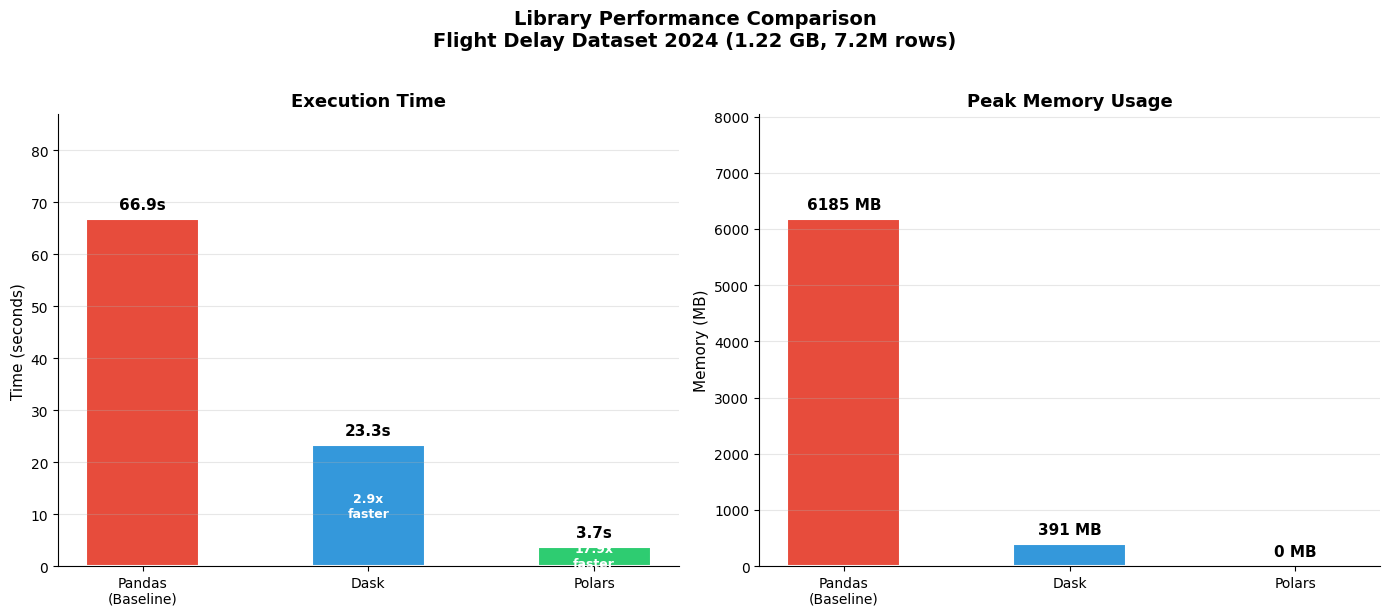

In [ ]:
import matplotlib.pyplot as plt

libraries   = ['Pandas\n(Baseline)', 'Dask', 'Polars']
times_load  = [baseline_time, s5a_time, s5b_time]
memory_peak = [baseline_memory, s5a_memory, s5b_memory]
colors      = ['#E74C3C', '#3498DB', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Library Performance Comparison\nFlight Delay Dataset 2024 (1.22 GB, 7.2M rows)',
             fontsize=14, fontweight='bold', y=1.02)

ax1 = axes[0]
bars1 = ax1.bar(libraries, times_load, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax1.set_title('Execution Time', fontsize=13, fontweight='bold')
ax1.set_ylabel('Time (seconds)', fontsize=11)
ax1.set_ylim(0, max(times_load) * 1.3)
for bar, val in zip(bars1, times_load):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(times_load) * 0.02,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
for i, (bar, t) in enumerate(zip(bars1, times_load)):
    if i > 0 and baseline_time > 0:
        speedup = baseline_time / t
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() / 2,
                 f'{speedup:.1f}x\nfaster', ha='center', va='center',
                 fontsize=9, color='white', fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(libraries, memory_peak, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax2.set_title('Peak Memory Usage', fontsize=13, fontweight='bold')
ax2.set_ylabel('Memory (MB)', fontsize=11)
ax2.set_ylim(0, max(memory_peak) * 1.3)
for bar, val in zip(bars2, memory_peak):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(memory_peak) * 0.02,
             f'{val:.0f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# **5.2 Chart 2 — All Strategies Overview**

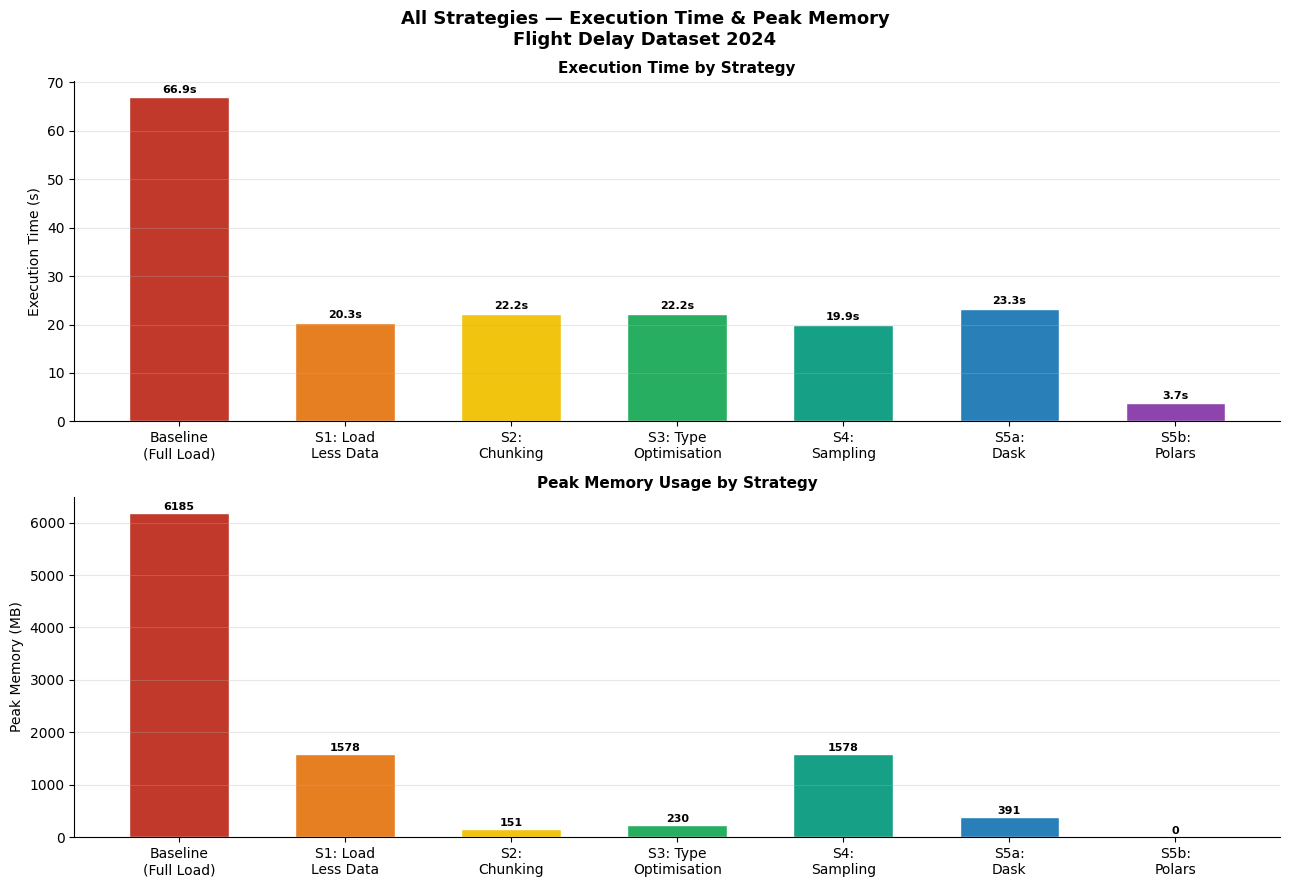

In [ ]:
import matplotlib.pyplot as plt

strategy_labels = [
    'Baseline\n(Full Load)',
    'S1: Load\nLess Data',
    'S2:\nChunking',
    'S3: Type\nOptimisation',
    'S4:\nSampling',
    'S5a:\nDask',
    'S5b:\nPolars'
]

strategy_times  = [baseline_time, s1_time, s2_time, s2_time, s4_time, s5a_time, s5b_time]
strategy_memory = [baseline_memory, s1_memory, s2_memory, after_memory, s4_memory, s5a_memory, s5b_memory]

strat_colors = ['#C0392B', '#E67E22', '#F1C40F', '#27AE60', '#16A085', '#2980B9', '#8E44AD']

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('All Strategies — Execution Time & Peak Memory\nFlight Delay Dataset 2024',
             fontsize=13, fontweight='bold')

ax = axes[0]
bars = ax.bar(strategy_labels, strategy_times, color=strat_colors, edgecolor='white', width=0.6)
ax.set_ylabel('Execution Time (s)', fontsize=10)
ax.set_title('Execution Time by Strategy', fontsize=11, fontweight='bold')
for bar, val in zip(bars, strategy_times):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}s', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(strategy_labels, strategy_memory, color=strat_colors, edgecolor='white', width=0.6)
ax2.set_ylabel('Peak Memory (MB)', fontsize=10)
ax2.set_title('Peak Memory Usage by Strategy', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, strategy_memory):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f'{val:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_all_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

# **5.3 Chart 3 — Radar Chart**

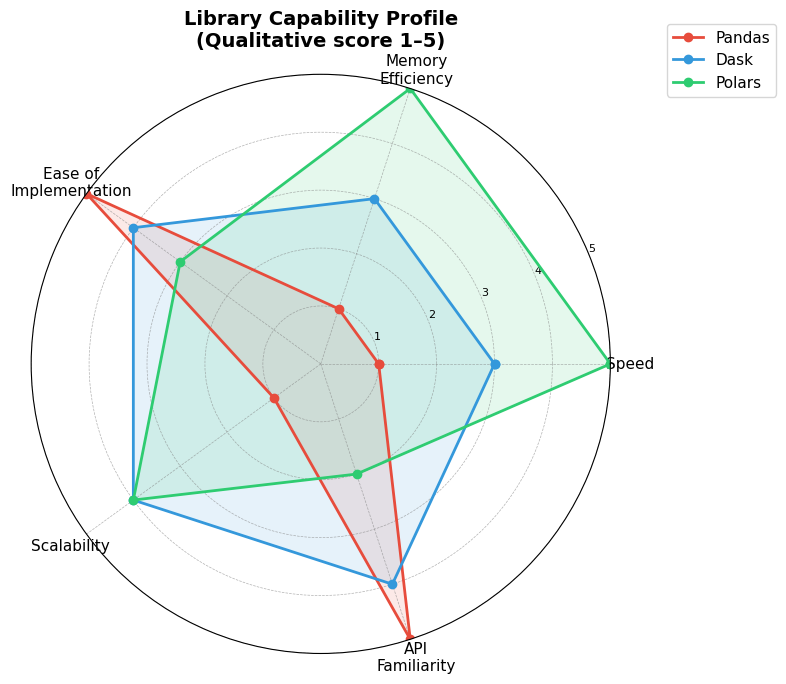

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Speed', 'Memory\nEfficiency', 'Ease of\nImplementation',
              'Scalability', 'API\nFamiliarity']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

scores = {
    'Pandas' : [1, 1, 5, 1, 5],
    'Dask'   : [3, 3, 4, 4, 4],
    'Polars' : [5, 5, 3, 4, 2],
}
lib_colors = {'Pandas': '#E74C3C', 'Dask': '#3498DB', 'Polars': '#2ECC71'}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for lib, vals in scores.items():
    vals_closed = vals + vals[:1]
    ax.plot(angles, vals_closed, 'o-', linewidth=2, label=lib, color=lib_colors[lib])
    ax.fill(angles, vals_closed, alpha=0.12, color=lib_colors[lib])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], size=8)
ax.set_ylim(0, 5)
ax.set_title('Library Capability Profile\n(Qualitative score 1–5)',
             size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('chart3_radar.png', dpi=150, bbox_inches='tight')
plt.show()